In [1]:
# --- Code cell 1 ---
import pandas as pd
import matplotlib.pyplot as plt
from lifelines.datasets import load_rossi

# Load the built-in dataset as a pandas DataFrame
rossi = load_rossi()

print("Rows, columns:", rossi.shape)
rossi.head()

Rows, columns: (432, 9)


,week,arrest,fin,age,race,wexp,mar,paro,prio
0,20,1,0,27,1,0,0,1,3
1,17,1,0,18,1,0,0,1,8
2,25,1,0,19,0,1,0,1,13
3,52,0,1,23,1,1,1,1,1
4,52,0,0,19,0,1,0,1,3


In [2]:
# --- Code cell 2 ---
# 1 = re-arrested (event observed), 0 = censored (no arrest seen during the study)
print(rossi["arrest"].value_counts())

# The study lasted 52 weeks, so no duration can be longer than that
print("Longest duration (weeks):", rossi["week"].max())

# Every censored person was followed for how long?
print("Durations of censored rows:", rossi.loc[rossi["arrest"] == 0, "week"].unique())

arrest
0    318
1    114
Name: count, dtype: int64
Longest duration (weeks): 52
Durations of censored rows: [52]


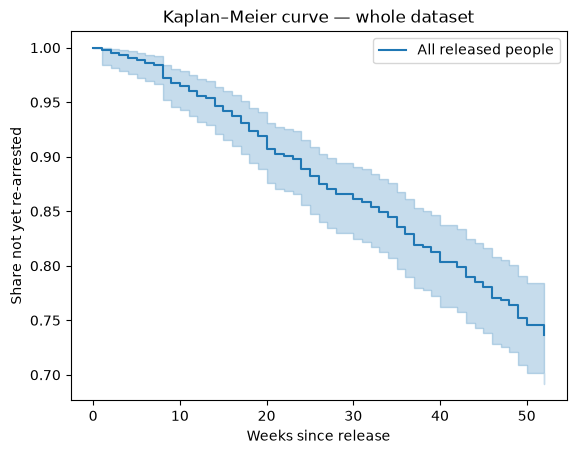

10    0.965278
26    0.875000
52    0.736111
Name: All released people, dtype: float64


In [3]:
# --- Code cell 3 ---
from lifelines import KaplanMeierFitter

# Create the estimator and fit it on the whole dataset
kmf = KaplanMeierFitter()
kmf.fit(durations=rossi["week"], event_observed=rossi["arrest"], label="All released people")

# Plot the survival curve; the shaded band is the 95% confidence interval
ax = kmf.plot_survival_function()
ax.set_xlabel("Weeks since release")
ax.set_ylabel("Share not yet re-arrested")
ax.set_title("Kaplan–Meier curve — whole dataset")
plt.show()

# Survival probability at a few chosen weeks
print(kmf.survival_function_at_times([10, 26, 52]))

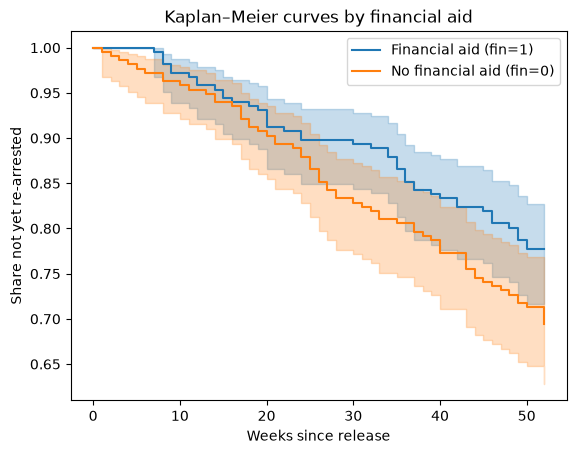

Group sizes: 216 with aid, 216 without aid
S(52) with aid:    0.778
S(52) without aid: 0.694


In [4]:
# --- Code cell 4 ---
# True/False mask: which rows received financial aid
has_aid = rossi["fin"] == 1

ax = plt.subplot(111)

# Fit and plot one curve per group on the same axes
kmf_aid = KaplanMeierFitter()
kmf_aid.fit(rossi.loc[has_aid, "week"], rossi.loc[has_aid, "arrest"], label="Financial aid (fin=1)")
kmf_aid.plot_survival_function(ax=ax)

kmf_no_aid = KaplanMeierFitter()
kmf_no_aid.fit(rossi.loc[~has_aid, "week"], rossi.loc[~has_aid, "arrest"], label="No financial aid (fin=0)")
kmf_no_aid.plot_survival_function(ax=ax)

ax.set_xlabel("Weeks since release")
ax.set_ylabel("Share not yet re-arrested")
ax.set_title("Kaplan–Meier curves by financial aid")
plt.show()

# Group sizes and survival probability at the end of the study (week 52)
print("Group sizes:", has_aid.sum(), "with aid,", (~has_aid).sum(), "without aid")
print("S(52) with aid:   ", round(kmf_aid.survival_function_at_times(52).iloc[0], 3))
print("S(52) without aid:", round(kmf_no_aid.survival_function_at_times(52).iloc[0], 3))

In [5]:
# --- Code cell 5 ---
from lifelines.statistics import logrank_test

# Compare the two groups: durations and event indicators for each
result = logrank_test(
    durations_A=rossi.loc[has_aid, "week"],
    durations_B=rossi.loc[~has_aid, "week"],
    event_observed_A=rossi.loc[has_aid, "arrest"],
    event_observed_B=rossi.loc[~has_aid, "arrest"],
)

print("Test statistic:", round(result.test_statistic, 3))
print("p-value:       ", round(result.p_value, 4))

Test statistic: 3.838
p-value:        0.0501


In [6]:
# --- Code cell 6 ---
from lifelines import CoxPHFitter

# Fit the Cox model: every column except week/arrest is used as a covariate
cph = CoxPHFitter()
cph.fit(rossi, duration_col="week", event_col="arrest")

# Keep the most important columns of the summary table
#   exp(coef) = hazard ratio, with its 95% confidence interval, and the p-value
columns = ["coef", "exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]
print("Concordance index:", round(cph.concordance_index_, 3))
cph.summary[columns].round(3)

Concordance index: 0.64


,coef,exp(coef),exp(coef) lower 95%,exp(coef) upper 95%,p
covariate,,,,,
fin,-0.379,0.684,0.470,0.996,0.047
age,-0.057,0.944,0.904,0.986,0.009
race,0.314,1.369,0.748,2.503,0.308
wexp,-0.150,0.861,0.568,1.305,0.480
mar,-0.434,0.648,0.307,1.370,0.256
paro,-0.085,0.919,0.626,1.348,0.665
prio,0.091,1.096,1.036,1.159,0.001


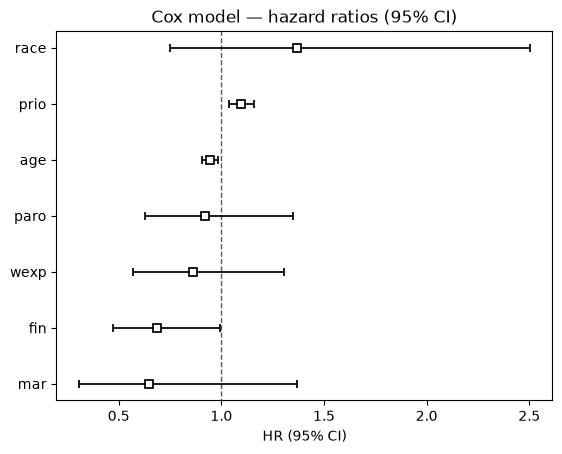

In [7]:
# --- Code cell 7 ---
# Plot the hazard ratios with their 95% confidence intervals.
# The vertical line at 1 means "no effect"; an interval that crosses it is not statistically significant.
ax = cph.plot(hazard_ratios=True)
ax.set_title("Cox model — hazard ratios (95% CI)")
plt.show()